## Set up data and model objects

In [1]:
import pandas as pd
import numpy as np

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from torch.distributions import NegativeBinomial
from pyro.distributions import LogNormalNegativeBinomial

from lightning.pytorch.callbacks import ModelCheckpoint

import mudata as md
import perturbo
import seaborn as sns
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt
import torch

smoke_test=False # only use selected genes
# smoke_test=False # run full analysis

torch.cuda.device_count()

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


0

In [2]:
import scvi
scvi.settings.seed = 0 

Global seed set to 0


Set training configuration and access to data

### Load the data
(50k cells, takes ~30 seconds)

In [3]:
data_dir = "../../../../Data/gasperini_pilot"
batch_size=4096 # multiple of 64

mdata = md.read_h5mu(f'{data_dir}/gasperini_pilot_highMOI.h5mu')

mdata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [4]:
# element_tested

In [5]:
targeted_genes = list({x.split("_")[0] for x in mdata["grna"].var_names if "TSS" in x})
targeted_genes_filtered = [x for x in targeted_genes if x in mdata["rna"].var_names]
# plt.hist(np.log10(mdata["rna"][:, targeted_genes].X.mean(axis=0).A1), bins=100)

In [6]:
mdata["rna"].X.mean()

0.9142034

In [7]:
mdata["rna"].X.mean(axis=1)

matrix([[1.2587525 ],
        [0.8583124 ],
        [0.83711123],
        ...,
        [0.787988  ],
        [0.8402273 ],
        [1.3630477 ]], dtype=float32)

(array([302., 334., 340., 334., 361., 354., 338., 374., 387., 356., 356.,
        332., 317., 296., 332., 338., 326., 324., 275., 292., 288., 298.,
        286., 315., 296., 305., 305., 294., 317., 308., 308., 312., 276.,
        275., 309., 308., 253., 295., 256., 247., 250., 235., 256., 234.,
        187., 196., 190., 184., 181., 174., 136., 132., 130., 109.,  99.,
        106.,  95.,  76.,  74.,  75.,  68.,  62.,  56.,  48.,  58.,  42.,
         43.,  41.,  37.,  26.,  29.,  27.,  15.,  16.,  13.,  16.,  14.,
         12.,  13.,  11.,  10.,   9.,   2.,   7.,   9.,   2.,   6.,   8.,
          2.,   2.,   3.,   4.,   3.,   2.,   4.,   0.,   3.,   4.,   0.,
          2.]),
 array([-1.99967492, -1.95736074, -1.91504645, -1.87273228, -1.83041799,
        -1.78810382, -1.74578953, -1.70347536, -1.66116118, -1.61884689,
        -1.57653272, -1.53421843, -1.49190426, -1.44958997, -1.4072758 ,
        -1.36496162, -1.32264733, -1.28033316, -1.23801887, -1.1957047 ,
        -1.15339041, -1.11

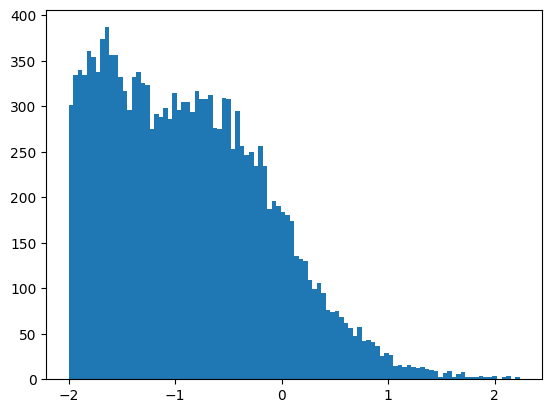

In [8]:
filtered_genes = (mdata["rna"].X>0).sum(axis=0) > 100
filtered_genes.sum()
plt.hist(np.log10(mdata["rna"][:, filtered_genes].X.mean(axis=0).A1), bins=100)

In [9]:
# data_dir = "/data/pinello/SHARED_DATA/gasperini_2019"
# data_dir = "/work/data/SHARED_DATA/gasperini_2019"

selected_guides = mdata["grna"].var_names[:100]
# selected_guides = ["ACTB_TSS|1", "ACTB_TSS|2", "ACTG1_TSS|1", "ACTG1_TSS|2"]
selected_genes = sorted({sg.split("_")[0] for sg in selected_guides})
selected_genes = [g for g in selected_genes if g in mdata["rna"].var_names]
if torch.cuda.is_available():
    accelerator = "gpu"
    print("training using GPU")
else:
    accelerator = "cpu"
    print("training using CPU")


training using CPU


In [10]:
if smoke_test:
    n_steps = 1
else:
    n_steps = scvi.model._utils.get_max_epochs_heuristic(len(mdata), epochs_cap=1000, decay_at_n_obs=5000)
n_steps

104

In [11]:
sceptre_df = pd.read_csv(f"{data_dir}/sceptre_results-2023_01_13.csv")
sceptre_df = sceptre_df.rename(columns={"gRNA_id": "guide", "gene_id": "gene", "z_value":"SCEPTRE_z_value","p_value":"SCEPTRE_p_value"})
sceptre_df


,gene,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
0,Y_RNA,ACTB_TSS|1,positive_control,0.940707,1.632176,0.469126
1,FOXK1,ACTB_TSS|1,positive_control,0.153629,-0.992648,-0.088097
2,AP5Z1,ACTB_TSS|1,positive_control,0.123562,-1.010549,-0.119240
3,RADIL,ACTB_TSS|1,positive_control,0.057483,-1.501497,-0.386814
4,RNF216P1,ACTB_TSS|1,positive_control,0.341734,-0.635756,-0.034944
...,...,...,...,...,...,...
22261,SNORD60,scrambled_9|2,negative_control,0.950426,1.765242,0.708387
22262,DCAKD,scrambled_9|2,negative_control,0.488787,-0.149950,-0.027133
22263,RNF213-AS1,scrambled_9|2,negative_control,0.847978,1.018406,0.507472
22264,NAPB,scrambled_9|2,negative_control,0.696904,0.508168,0.149431


In [12]:
if not smoke_test or selected_genes is None:
    selected_genes = sceptre_df["gene"].unique()
if not smoke_test or selected_guides is None:
    selected_guides = sceptre_df["guide"].unique()

print(len(selected_genes), len(selected_guides))
# sceptre_df.query("guide=='GATA2_TSS|1'")


5859 1243


In [13]:
sceptre_df.query("pair_type=='negative_control'")

,gene,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
21272,Metazoa_SRP,random_1|1,negative_control,0.225595,-0.745345,-0.331922
21273,OR2G6,random_1|1,negative_control,0.985559,2.585539,0.942606
21274,SLC3A2,random_1|1,negative_control,0.874096,1.930871,0.153495
21275,PTPN11,random_1|1,negative_control,0.685826,0.454581,0.040252
21276,CORO7,random_1|1,negative_control,0.847094,1.114626,0.175454
...,...,...,...,...,...,...
22261,SNORD60,scrambled_9|2,negative_control,0.950426,1.765242,0.708387
22262,DCAKD,scrambled_9|2,negative_control,0.488787,-0.149950,-0.027133
22263,RNF213-AS1,scrambled_9|2,negative_control,0.847978,1.018406,0.507472
22264,NAPB,scrambled_9|2,negative_control,0.696904,0.508168,0.149431


In [14]:
grna_subset = mdata.mod['grna'][:,selected_guides]
# grna_subset.X *= 0 # NO GUIDE INFLUENCE
rna_subset = mdata.mod['rna'][:,selected_genes]
mdata = md.MuData({'rna':rna_subset, 'grna':grna_subset}).copy()
mdata

MuData object with n_obs × n_vars = 47964 × 7102
  2 modalities
    rna:	47964 x 5859
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [15]:
mdata['grna'].varm['element_targeted']


,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,scrambled_24,scrambled_25,scrambled_2,scrambled_3,scrambled_4,scrambled_5,scrambled_6,scrambled_7,scrambled_8,scrambled_9
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Register data with perturbo

In [16]:
# element_names1 = model.adata_manager.get_state_registry("tested_elements")['column_names']
# element_names2 = model.adata_manager.get_state_registry("targeted_elements")['column_names']
# assert element_names1 == element_names2

In [17]:
# %pip install scikit-misc

In [18]:
# sc.pp.highly_variable_genes(mdata['rna'], flavor='seurat_v3', batch_key="bath_number", n_top_genes=1000)
# # sc.pp.neighbors(mdata['rna'])
# sc.tl.pca(mdata['rna'])


In [19]:
mdata['rna'].obs

,bath_number,percent_mito,log_number_of_detected_genes,log_total_gene_count,log_total_guide_count,library_size
TTGAACGCAAGCGAGT,6,0.029057,8.385489,8.385717,7.330405,20602.0
ATTACTCGTGGTAACG,1,0.025976,8.254529,8.254789,5.986452,14048.0
GTAGTCATCGTTGACA,5,0.042747,8.206584,8.206856,5.225747,13701.0
GTGTGCGTCCCGACTT,4,0.042587,8.327726,8.327968,5.700444,17474.0
GCATGCGAGAAACGAG,3,0.021318,7.806289,7.806696,7.071573,8807.0
...,...,...,...,...,...,...
GGAATAATCTGGGCCA,3,0.091893,8.316056,8.316300,5.793014,15244.0
GTCCTCATCTTGTATC,6,0.043563,7.293698,7.294377,6.093570,3588.0
CCACTACGTAGAGCTG,6,0.021208,8.134761,8.135054,6.400258,12897.0
CGTTCTGAGGATGGTC,6,0.025178,8.203851,8.204125,5.730100,13752.0


In [20]:
mdata[mdata['rna'].obs['percent_mito']<0.1,:]

View of MuData object with n_obs × n_vars = 47679 × 7102
  2 modalities
    rna:	47679 x 5859
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47679 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scanpy/plotting/_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


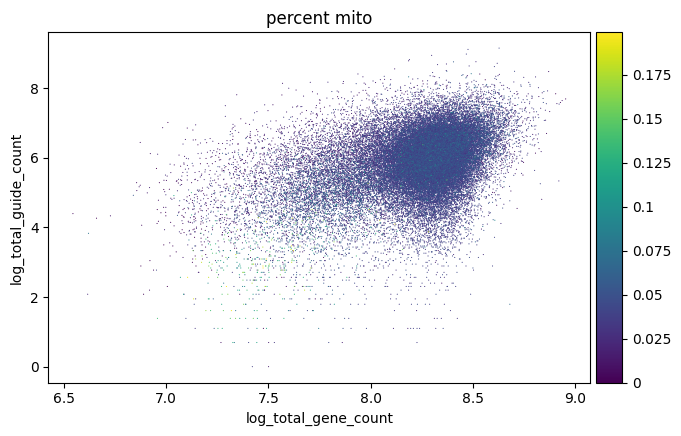

In [21]:
# mdata.update()
import scanpy as sc

# mdata = mdata[mdata['rna'].obs['percent_mito']<0.1,:].copy()
# mdata = mdata[mdata['rna'].obs['log_total_gene_count'].between(8.1,8.5),:].copy()
sc.pl.scatter(mdata['rna'],"log_total_gene_count", "log_total_guide_count", "percent_mito")
# mdata

In [22]:
# sc.pl.pca(mdata['rna'], color="bath_number")
# sc.pl.pca(mdata['rna'], color="percent_mito")
mdata['rna'].X.mean(axis=0).shape

(1, 5859)

In [23]:
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="bath_number",
    library_size_key="library_size",
    continuous_covariates_keys=["log_total_guide_count", "percent_mito"],
    guide_by_element_key="element_targeted",
    gene_by_element_key="element_tested",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood="nb", n_factors=5, n_pert_factors=20)
model.view_anndata_setup()


<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For cre

INFO     Using column names from columns of adata.varm['element_tested']                                           
INFO     Using column names from columns of adata.varm['element_targeted']                                         


Anndata setup with scvi-tools version 1.0.4.

Setup via `PERTURBO.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'perturbation_layer': None,
│   'batch_key': 'bath_number',
│   'gene_by_element_key': 'element_tested',
│   'rna_element_uns_key': None,
│   'guide_element_uns_key': None,
│   'guide_by_element_key': 'element_targeted',
│   'library_size_key': 'library_size',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['log_total_guide_count', 'percent_mito'],
│   'categorical_covariates_keys': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'}
}

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   6   │
│         n_cells         │ 47964 │
│ n_extra_continuous_covs │   2   │
│  n_gene_summary_stats   │   1   │
│     n_perturbations     │ 1243  │
│   n_targeted_elements   │ 1561  │
│    n_tested_elements    │ 1561  │
│         n_vars          │ 5859  │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│  gene_summary_stats   │  adata.mod['rna'].varm['_scvi_gene_summary_stats']   │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │      adata.mod['grna'].varm['element_targeted']      │
│    tested_elements    │       adata.mod['rna'].varm['element_tested']        │
└───────────────────────┴──────────────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['bath_number'] │     1      │          0          │
│                          │     2      │          1          │
│                          │     3      │          2          │
│                          │     4      │          3          │
│                          │     5      │          4          │
│                          │     6      │          5          │
└──────────────────────────┴────────────┴─────────────────────┘

 gene_summary_stats State  
         Registry          
┏━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.var['_gene_mean'] │
└─────────────────────────┘

 extra_continuous_covs State Registry 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃          Source Location           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['log_total_guide_count'] │
│     adata.obs['percent_mito']      │
└────────────────────────────────────┘

### Train the model

In [24]:
list(pyro.get_param_store().keys())


[]

In [25]:
# burn-in
pyro.clear_param_store()

# len(mdata['rna'])/batch_size
# # 0.9**(1/11)# from pyro.optim import ClippedAdam
from torch.optim import Adam
from pyro.infer import TraceMeanField_ELBO
from math import ceil
from torch.optim.lr_scheduler import ReduceLROnPlateau
optimizer = Adam

# scheduler = ReduceLROnPlateau(optimizer, patience=2, verbose=True)
steps_per_epoch = ceil(model.module.n_cells / batch_size)
# scheduler = pyro.optim.MultiStepLR(
#     {
#         "optimizer": optimizer,
#         "optim_args": {"lr": 0.1},
#         "gamma": 0.3,
#         # "milestones": [steps_per_epoch * 10, steps_per_epoch*20],
#         "milestones": [10, 20],
#     }
# )

# scheduler = pyro.optim.ReduceLROnPlateau(
#     {
#         "optimizer": optimizer,
#         "optim_args": {"lr": 0.1},
#         "threshold": 1e-2,
#         "patience": 5,
#         "factor": 0.3,
#     }
# )


def plot_gene_distribution(medians, gene_name="ACTB", x_max=100, log_y_scale=False):
    gene_idx = np.where(mdata["rna"].var_names == gene_name)[0][0]
    tss_guides = mdata["grna"].var_names[mdata["grna"].var_names.str.startswith(gene_name + "_TSS")]
    has_tss_guide = mdata["grna"][:, tss_guides].X.sum(axis=1) > 0
    data_df = mdata["rna"][:, gene_idx].to_df()
    data_df["has_TSS_guide"] = has_tss_guide
    print(has_tss_guide.shape)
    print(tss_guides)
    log_gene_means = medians["log_gene_mean"]
    log_gene_dispersions = medians["log_gene_dispersion"]
    x = torch.tensor(np.arange(x_max))
    logit = log_gene_means[gene_idx]
    total_count = log_gene_dispersions[gene_idx].exp()
    if model.module.likelihood == "nb":
        ndist = NegativeBinomial(logits=logit - total_count.log(), total_count=total_count)
    elif model.module.likelihood == "lnnb":
        multiplicative_noise = medians["multiplicative_noise"][gene_idx]
        ndist = LogNormalNegativeBinomial(
            logits=logit - total_count.log() - multiplicative_noise**2 / 2,
            total_count=total_count,
            multiplicative_noise_scale=multiplicative_noise,
            num_quad_points=32,
        )
    probs = ndist.log_prob(x).exp()
    plt.plot(x, probs)
    sns.histplot(data_df, x=gene_name, bins=x, stat="density", hue="has_TSS_guide")
    plt.title(f'gene: {mdata["rna"].var_names[gene_idx]}')
    print(f'logit={logit:.2f}, total_count={total_count:.2f}')
    if model.module.likelihood == "lnnb":
        print(f'multiplicative_noise={multiplicative_noise:.2f}')
    if log_y_scale:
        plt.semilogy()
    plt.show()
    return data_df

In [26]:
# model.train(
#     1,
#     lr=0.000001,
#     batch_size=128,
#     accelerator=accelerator,
# )
# plot_gene_distribution(model.module.guide.median())

In [27]:
model

MyPyroModel Model with params:
n_batch: 6
n_cells: 47964
n_extra_continuous_covs: 2
n_gene_summary_stats: 1
n_perturbations: 1243
n_targeted_elements: 1561
n_tested_elements: 1561
n_vars: 5859

Training status: Not Trained
Model's adata is minified?: False

In [28]:
from lightning.pytorch.callbacks import Callback

medians = []
# n_epochs=100
# for _ in range(n_epochs):

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/", every_n_epochs=10, save_top_k=-1, save_on_train_epoch_end=True
)



# model.train(
#     100,
#     lr=0.003,
#     batch_size=512,
#     callbacks=[checkpoint_callback],
#     enable_checkpointing=True,
#     early_stopping=True,
#     early_stopping_patience=2,
#     early_stopping_min_delta=1e-2,
#     early_stopping_monitor="elbo_train",
# )

model.train(
    100,
    lr=0.01,
    batch_size=512,
    callbacks=[checkpoint_callback],
    enable_checkpointing=True,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_min_delta=1e-3,
    early_stopping_monitor="elbo_train",
)


# medians.append(model.module.guide.median())

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint directory checkpoints/ exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")


Epoch 73/100:  73%|███████▎  | 73/100 [26:46<09:54, 22.01s/it, v_num=1, elbo_train=2.14e+8]
Monitored metric elbo_train did not improve in the last 5 records. Best score: 213986256.000. Signaling Trainer to stop.


In [29]:
# checkpoint = torch.load("checkpoints/epoch=9-step=660.ckpt")
# checkpoint = torch.load("checkpoints/epoch=89-step=5940.ckpt")

# state_model.module.load_state_dict(checkpoint["state_dict"])
# offset = len("module.")
# new_dict = {k[len("module."):]: v for k, v in checkpoint["state_dict"].items() if k != "_dummy_param"}

# model.module.load_state_dict(new_dict)
# model.module.guide.median()åååå
# for k, v in checkpoint["state_dict"].items():
    # print(k)

In [30]:
model

MyPyroModel Model with params:
n_batch: 6
n_cells: 47964
n_extra_continuous_covs: 2
n_gene_summary_stats: 1
n_perturbations: 1243
n_targeted_elements: 1561
n_tested_elements: 1561
n_vars: 5859

Training status: Trained
Model's adata is minified?: False

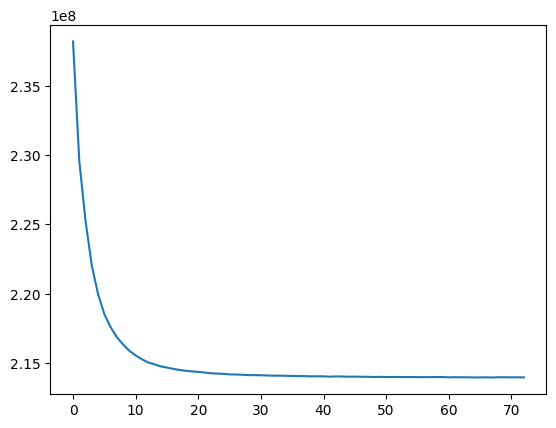

In [31]:
plt.plot(model.history["elbo_train"])

In [32]:
# efficacy = torch.stack([m["guide_efficacy"].squeeze() for m in medians])
# for i, guide in enumerate(mdata["grna"].var_names):
#     plt.plot(range(n_epochs), efficacy[:,i], label=guide)
# plt.legend()

In [33]:
# mean = torch.stack([m["log_gene_mean"].squeeze() for m in medians])
# for i, guide in enumerate(mdata["rna"].var_names):
#     plt.plot(range(n_epochs), mean[:,i], label=guide)
# plt.legend()

In [34]:
# disp = torch.stack([m["log_gene_dispersion"].squeeze() for m in medians])
# for i, guide in enumerate(mdata["rna"].var_names):
#     plt.plot(range(n_epochs), disp[:,i], label=guide)
# plt.legend()
# plt.title("log gene dispersion")

In [35]:
# extra_noise = torch.stack([m["multiplicative_noise"].squeeze() for m in medians])
# for i, guide in enumerate(mdata["rna"].var_names):
#     plt.plot(range(n_epochs), extra_noise[:,i], label=guide)
# plt.legend()
# plt.title("extra multiplicative noise")

In [36]:
# for sg in selected_genes:
#     plot_gene_distribution(model.module.guide.median(), gene_name=sg, log_y_scale=True)

In [37]:
# for sg in selected_genes:
    # plot_gene_distribution(model.module.guide.median(), gene_name=sg, log_y_scale=False)

In [38]:

# for _ in range(10):
#     model.train(
#         10,
#         lr=0.01,
#         batch_size=1024,
#         accelerator=accelerator,
#     )
#     plot_gene_distribution(model.module.guide.median())


# # plan_kwargs = {'optim': pyro.optim.ClippedAdam(dict(lr=0.1, lrd=0.96))}
# # model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)
# # model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)


In [39]:
# medians = model.module.guide.median()
# log_gene_means = medians["log_gene_mean"]
# log_gene_dispersions = medians["log_gene_dispersion"]
# @interact(gene_idx = (0, mdata["rna"].n_vars), x_max=(0,100))
# def plot_gene_distribution(gene_idx=0, x_max=20, log_y_scale=False):
#     x = torch.tensor(np.arange(x_max))
#     logit = log_gene_means[gene_idx]
#     total_count = log_gene_dispersions[gene_idx].exp()
#     ndist = NegativeBinomial(logits = logit-log_gene_dispersions[gene_idx], total_count=total_count)
#     probs = ndist.log_prob(x).exp()
#     plt.plot(x, probs)
#     plt.hist(mdata["rna"].X[:,gene_idx].todense(), bins=x, density=True)
#     plt.title(f'gene: {mdata["rna"].var_names[gene_idx]}, logit={logit:.2f}, total_count={total_count:.2f}')
#     if log_y_scale:
#         plt.semilogy()

In [40]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)

AutoGuideList.0.locs.guide_efficacy torch.Size([1243, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([1243, 1])
AutoGuideList.0.locs.pert_factors torch.Size([20, 1561, 1])
AutoGuideList.0.scales.pert_factors torch.Size([20, 1561, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([20, 1, 5859])
AutoGuideList.0.scales.pert_loadings torch.Size([20, 1, 5859])
AutoGuideList.0.locs.cell_factors torch.Size([5, 47964, 1])
AutoGuideList.0.scales.cell_factors torch.Size([5, 47964, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([5, 1, 5859])
AutoGuideList.0.scales.cell_loadings torch.Size([5, 1, 5859])
AutoGuideList.0.locs.pert_cell_factors torch.Size([5, 1561, 1])
AutoGuideList.0.scales.pert_cell_factors torch.Size([5, 1561, 1])
AutoGuideList.0.locs.log_gene_mean torch.Size([5859])
AutoGuideList.0.scales.log_gene_mean torch.Size([5859])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([5859])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([5859])
AutoGuideList.0.locs.batch_eff

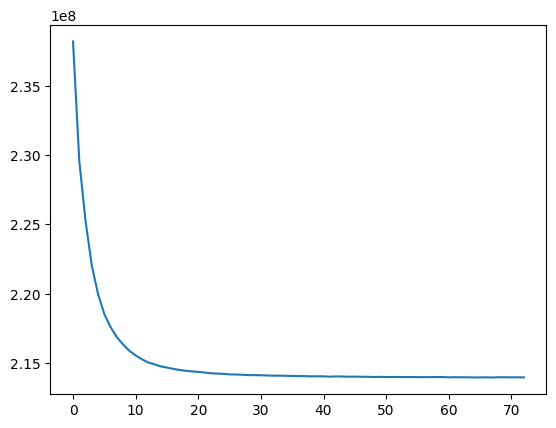

In [41]:
plt.plot(model.history["elbo_train"])


In [42]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)

AutoGuideList.0.locs.guide_efficacy torch.Size([1243, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([1243, 1])
AutoGuideList.0.locs.pert_factors torch.Size([20, 1561, 1])
AutoGuideList.0.scales.pert_factors torch.Size([20, 1561, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([20, 1, 5859])
AutoGuideList.0.scales.pert_loadings torch.Size([20, 1, 5859])
AutoGuideList.0.locs.cell_factors torch.Size([5, 47964, 1])
AutoGuideList.0.scales.cell_factors torch.Size([5, 47964, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([5, 1, 5859])
AutoGuideList.0.scales.cell_loadings torch.Size([5, 1, 5859])
AutoGuideList.0.locs.pert_cell_factors torch.Size([5, 1561, 1])
AutoGuideList.0.scales.pert_cell_factors torch.Size([5, 1561, 1])
AutoGuideList.0.locs.log_gene_mean torch.Size([5859])
AutoGuideList.0.scales.log_gene_mean torch.Size([5859])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([5859])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([5859])
AutoGuideList.0.locs.batch_eff

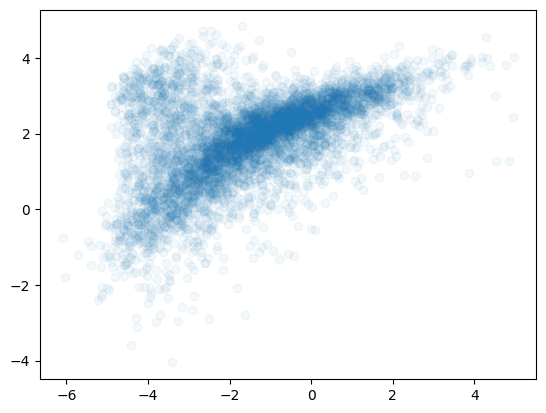

In [43]:
mean = model.module.guide.median()['log_gene_mean'].numpy()
dispersion = model.module.guide.median()['log_gene_dispersion'].numpy()
plt.scatter(mean, dispersion, alpha=0.05)


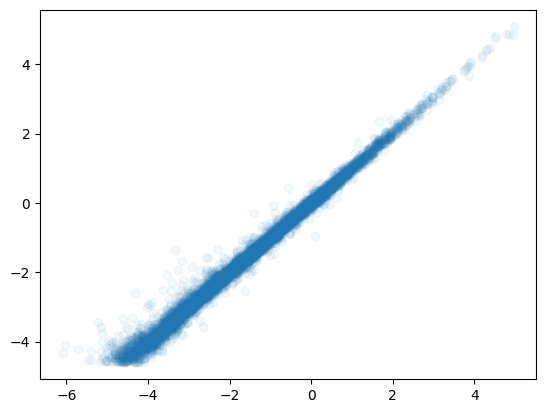

In [44]:
plt.scatter(mean, np.log(mdata['rna'].X.mean(axis=0).A1), alpha=0.05)


In [45]:

from scipy.sparse import coo_matrix, issparse

element_effects = model.get_element_effects()
element_effects = element_effects.assign(
    is_target=lambda x: x["element"].str.split("_", expand=True)[0] == x["gene"],
)
element_effects

,loc,scale,element,gene,z_value,q_value,is_target
865,-6.666205,0.062372,CHCHD10_TSS,CHCHD10,-106.878807,0.000000e+00,True
483,-4.333251,0.041430,BTF3_TSS,BTF3,-104.591782,0.000000e+00,True
3982,-6.669413,0.070831,PARK7_TSS,PARK7,-94.159111,0.000000e+00,True
5050,-4.138899,0.050222,RPL29_TSS,RPL29,-82.411842,0.000000e+00,True
2089,-7.303787,0.092404,GAL_TSS,GAL,-79.041473,0.000000e+00,True
...,...,...,...,...,...,...,...
2564,1.086742,0.148804,IMPDH2_TSS,NDUFAF3,7.303163,2.810804e-13,False
8417,3.661473,0.415503,chr11:64102407-64102430,PRDX5,8.812141,1.227774e-18,False
1538,1.171598,0.119469,EEF2_TSS,MYDGF,9.806672,1.053871e-22,False
5828,5.962712,0.538731,TFRC_TSS,LINC00885,11.068070,1.792180e-28,False


<Axes: >

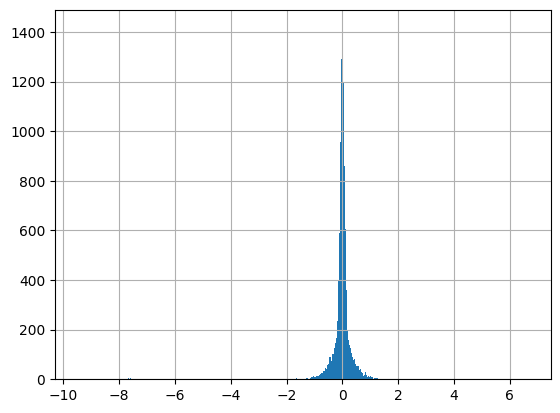

In [46]:
element_effects['loc'].hist(bins=1000)
# plt.semilogy()
# plt.xlim([-5,5])

/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_56545/3333580445.py:1: FutureWarning: 

The `scale` parameter has been renamed to `width_method` and will be removed in v0.15. Pass `width_method='area', but note that the result for 'area' will appear different.
  sns.boxenplot(element_effects, x="is_target", y="z_value", scale="area")


<Axes: xlabel='is_target', ylabel='z_value'>

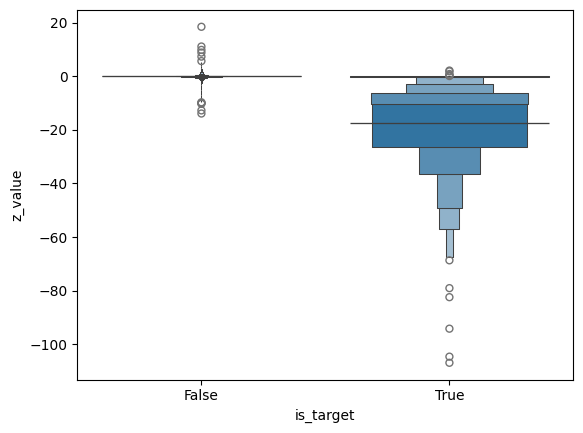

In [47]:
sns.boxenplot(element_effects, x="is_target", y="z_value", scale="area")

In [48]:
# scpower_df.sort_values('p_value')
sceptre_df=sceptre_df.assign(element=lambda x: x['guide'].str.split(r'|', regex=False, expand=True)[0])


In [49]:
merge_df = element_effects.merge(sceptre_df, how="inner", on=["element", "gene"])

if not smoke_test:
    assert len(merge_df)==len(sceptre_df)

# len(merge_df)
# # merge_df.sort_values("SCEPTRE_p_value")

## Visualize hits



In [50]:
from sklearn.linear_model import LinearRegression

reg_x=(merge_df[["z_value"]].values)
reg_y=(merge_df[["SCEPTRE_z_value"]].values)
reg = LinearRegression(fit_intercept=False).fit(reg_x, reg_y)
print("slope:", reg.coef_[0,0])
print("R^2:", reg.score(reg_x, reg_y))


slope: 0.53640485
R^2: 0.7944281621237614


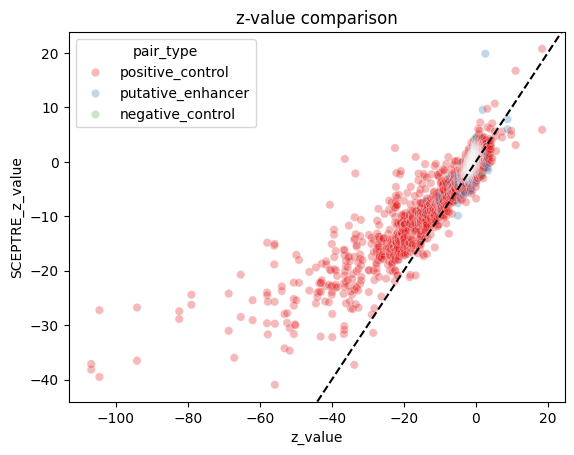

In [51]:
plt.title("z-value comparison")
sns.scatterplot(merge_df, x='z_value', y='SCEPTRE_z_value', hue='pair_type', alpha=0.3, palette='Set1')
plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
plt.show()


## Interactive data visualization
Need to subset and clip the data so that we can plot interactively

(1e-21, 2)

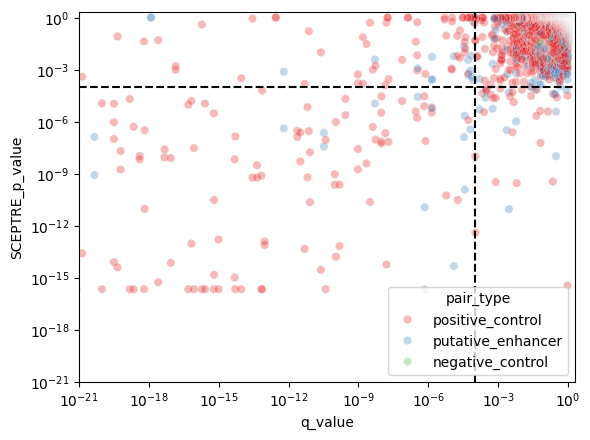

In [52]:
# merge_df['p_value'] = np.maximum(merge_df['p_value'], min_p_value)

sns.scatterplot(merge_df, x="q_value", y="SCEPTRE_p_value", hue="pair_type", alpha=0.3, palette="Set1")
# plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
plt.axhline(1e-4, c='black', linestyle='dashed')
plt.axvline(1e-4,  c='black', linestyle='dashed')

plt.loglog()
# plt.legend()
plt.xlim(1e-21, 2)
plt.ylim(1e-21, 2)

In [53]:
min_p_value = 1e-100

subset_results = merge_df.query("q_value<0.01 or SCEPTRE_p_value < 0.01").copy()
# subset_results = merge_df.query("p_value<1e-5")
subset_results['p_value'] = np.maximum(subset_results['q_value'], min_p_value)
subset_results

,loc,scale,element,gene,z_value,q_value,is_target,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change,p_value
0,-6.666205,0.062372,CHCHD10_TSS,CHCHD10,-106.878807,0.000000e+00,True,CHCHD10_TSS|1,positive_control,2.220446e-16,-38.174558,-1.769527,1.000000e-100
1,-6.666205,0.062372,CHCHD10_TSS,CHCHD10,-106.878807,0.000000e+00,True,CHCHD10_TSS|2,positive_control,2.220446e-16,-37.144596,-1.268803,1.000000e-100
2,-4.333251,0.041430,BTF3_TSS,BTF3,-104.591782,0.000000e+00,True,BTF3_TSS|1,positive_control,2.220446e-16,-27.260327,-0.798275,1.000000e-100
3,-4.333251,0.041430,BTF3_TSS,BTF3,-104.591782,0.000000e+00,True,BTF3_TSS|2,positive_control,2.220446e-16,-39.518414,-0.861200,1.000000e-100
4,-6.669413,0.070831,PARK7_TSS,PARK7,-94.159111,0.000000e+00,True,PARK7_TSS|1,positive_control,2.220446e-16,-26.772522,-1.496455,1.000000e-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22261,1.171598,0.119469,EEF2_TSS,MYDGF,9.806672,1.053871e-22,False,EEF2_TSS|2,positive_control,9.999990e-01,5.701977,0.160159,1.053871e-22
22262,5.962712,0.538731,TFRC_TSS,LINC00885,11.068070,1.792180e-28,False,TFRC_TSS|1,positive_control,1.000000e+00,16.712611,1.359755,1.792180e-28
22263,5.962712,0.538731,TFRC_TSS,LINC00885,11.068070,1.792180e-28,False,TFRC_TSS|2,positive_control,9.974150e-01,3.065988,0.482996,1.792180e-28
22264,6.662271,0.361551,TFRC_TSS,ZDHHC19,18.426935,7.988221e-76,False,TFRC_TSS|1,positive_control,1.000000e+00,20.749277,1.190958,7.988221e-76


In [54]:
pos_controls = merge_df.query("pair_type=='positive_control'")
pos_controls=pos_controls[~pos_controls['gene'].str.contains("-AS")] # remove alt start sites
pos_controls=pos_controls.assign(
    perturbo_rank=lambda x: x.groupby('guide')['q_value'].rank(),
    perturbo_p_rank=lambda x: x.groupby('guide')['z_value'].rank(),
    SCEPTRE_p_rank=lambda x: x.groupby('guide')['SCEPTRE_p_value'].rank(),
    SCEPTRE_z_rank=lambda x: x.groupby('guide')['SCEPTRE_z_value'].rank()
)
pos_controls

,loc,scale,element,gene,z_value,q_value,is_target,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change,perturbo_rank,perturbo_p_rank,SCEPTRE_p_rank,SCEPTRE_z_rank
0,-6.666205,0.062372,CHCHD10_TSS,CHCHD10,-106.878807,0.000000e+00,True,CHCHD10_TSS|1,positive_control,2.220446e-16,-38.174558,-1.769527,1.0,1.0,1.0,1.0
1,-6.666205,0.062372,CHCHD10_TSS,CHCHD10,-106.878807,0.000000e+00,True,CHCHD10_TSS|2,positive_control,2.220446e-16,-37.144596,-1.268803,1.0,1.0,1.0,1.0
2,-4.333251,0.041430,BTF3_TSS,BTF3,-104.591782,0.000000e+00,True,BTF3_TSS|1,positive_control,2.220446e-16,-27.260327,-0.798275,1.0,1.0,1.0,1.0
3,-4.333251,0.041430,BTF3_TSS,BTF3,-104.591782,0.000000e+00,True,BTF3_TSS|2,positive_control,2.220446e-16,-39.518414,-0.861200,1.0,1.0,1.0,1.0
4,-6.669413,0.070831,PARK7_TSS,PARK7,-94.159111,0.000000e+00,True,PARK7_TSS|1,positive_control,2.220446e-16,-26.772522,-1.496455,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22261,1.171598,0.119469,EEF2_TSS,MYDGF,9.806672,1.053871e-22,False,EEF2_TSS|2,positive_control,9.999990e-01,5.701977,0.160159,2.0,46.0,46.0,46.0
22262,5.962712,0.538731,TFRC_TSS,LINC00885,11.068070,1.792180e-28,False,TFRC_TSS|1,positive_control,1.000000e+00,16.712611,1.359755,2.0,27.0,27.0,27.0
22263,5.962712,0.538731,TFRC_TSS,LINC00885,11.068070,1.792180e-28,False,TFRC_TSS|2,positive_control,9.974150e-01,3.065988,0.482996,2.0,27.0,27.0,27.0
22264,6.662271,0.361551,TFRC_TSS,ZDHHC19,18.426935,7.988221e-76,False,TFRC_TSS|1,positive_control,1.000000e+00,20.749277,1.190958,1.0,28.0,28.0,28.0


In [55]:
target_pairs = pos_controls.query('is_target')
print("our accuracy: "+str(len(target_pairs.query('perturbo_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_z_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_p_rank==1'))/len(target_pairs)))

our accuracy: 0.9617486338797814
SCEPTRE accuracy: 0.924863387978142
SCEPTRE accuracy: 0.9153005464480874


In [56]:
# target_pairs.query('perturbo_rank==1 and SCEPTRE_z_rank>=2')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
target_pairs.query('perturbo_rank==1 and SCEPTRE_p_rank>1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
# target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

,guide,gene,perturbo_rank,SCEPTRE_p_rank
63,KRT18_TSS|1,KRT18,1.0,2.0
96,SLC25A39_TSS|2,SLC25A39,1.0,30.0
123,PPM1G_TSS|1,PPM1G,1.0,4.0
159,COMT_TSS|1,COMT,1.0,1.5
234,SRP14_TSS|2,SRP14,1.0,24.0
365,TTC3_TSS|1,TTC3,1.0,1.5
366,TTC3_TSS|2,TTC3,1.0,1.5
367,MND1_TSS|1,MND1,1.0,2.0
385,NDUFB7_TSS|1,NDUFB7,1.0,32.0
443,MRPL4_TSS|1,MRPL4,1.0,4.0


In [57]:
target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

,guide,gene,perturbo_rank,SCEPTRE_p_rank
657,TFRC_TSS|1,TFRC,3.0,1.0
658,TFRC_TSS|2,TFRC,3.0,1.0
2391,ID3_TSS|1,ID3,3.0,1.0
2392,ID3_TSS|2,ID3,3.0,1.0
7269,MTRNR2L8_TSS|1,MTRNR2L8,7.0,1.0
8190,MAN1A1_TSS|2,MAN1A1,4.0,1.0


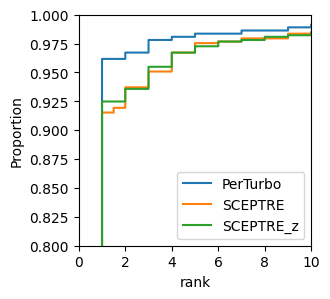

In [58]:
with plt.rc_context({"figure.figsize": [3,3]}):

  sns.ecdfplot(pos_controls.query('is_target'), x='perturbo_rank',stat="proportion", label="PerTurbo")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_p_rank',stat="proportion", label="SCEPTRE")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_z_rank',stat="proportion", label="SCEPTRE_z")
  plt.legend()
  # plt.title("eCDF")
  # plt.semilogy()
  plt.xlabel("rank")
  plt.xlim([0,10])
  plt.ylim(0.8, 1)
  plt.show()

0.9528138682216943 0.9234061231976527


Text(0.5, 1.0, 'perturbo vs. SCEPTRE p-values')

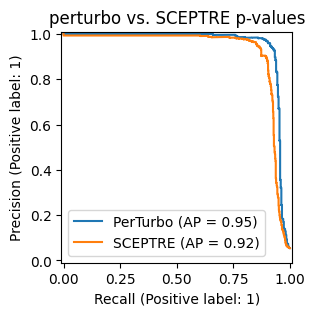

In [59]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['z_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'], ax=roc.ax_, name="SCEPTRE")

precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], 1-pos_controls['z_value'])
score2=average_precision_score(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'])
print(score1, score2)
plt.title("perturbo vs. SCEPTRE p-values")
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


0.9528138682216943 0.9304176453265475


Text(0.5, 1.0, 'z-values')

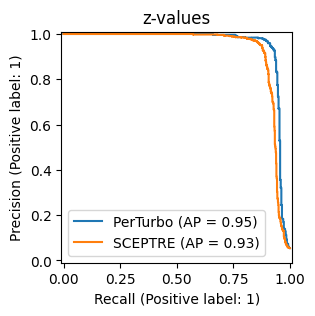

In [60]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['z_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'], ax=roc.ax_, name="SCEPTRE")


precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], -pos_controls['z_value'])
score2=average_precision_score(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'])
print(score1, score2)
plt.title('z-values')
# plt.title()
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


## experimental/future 

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


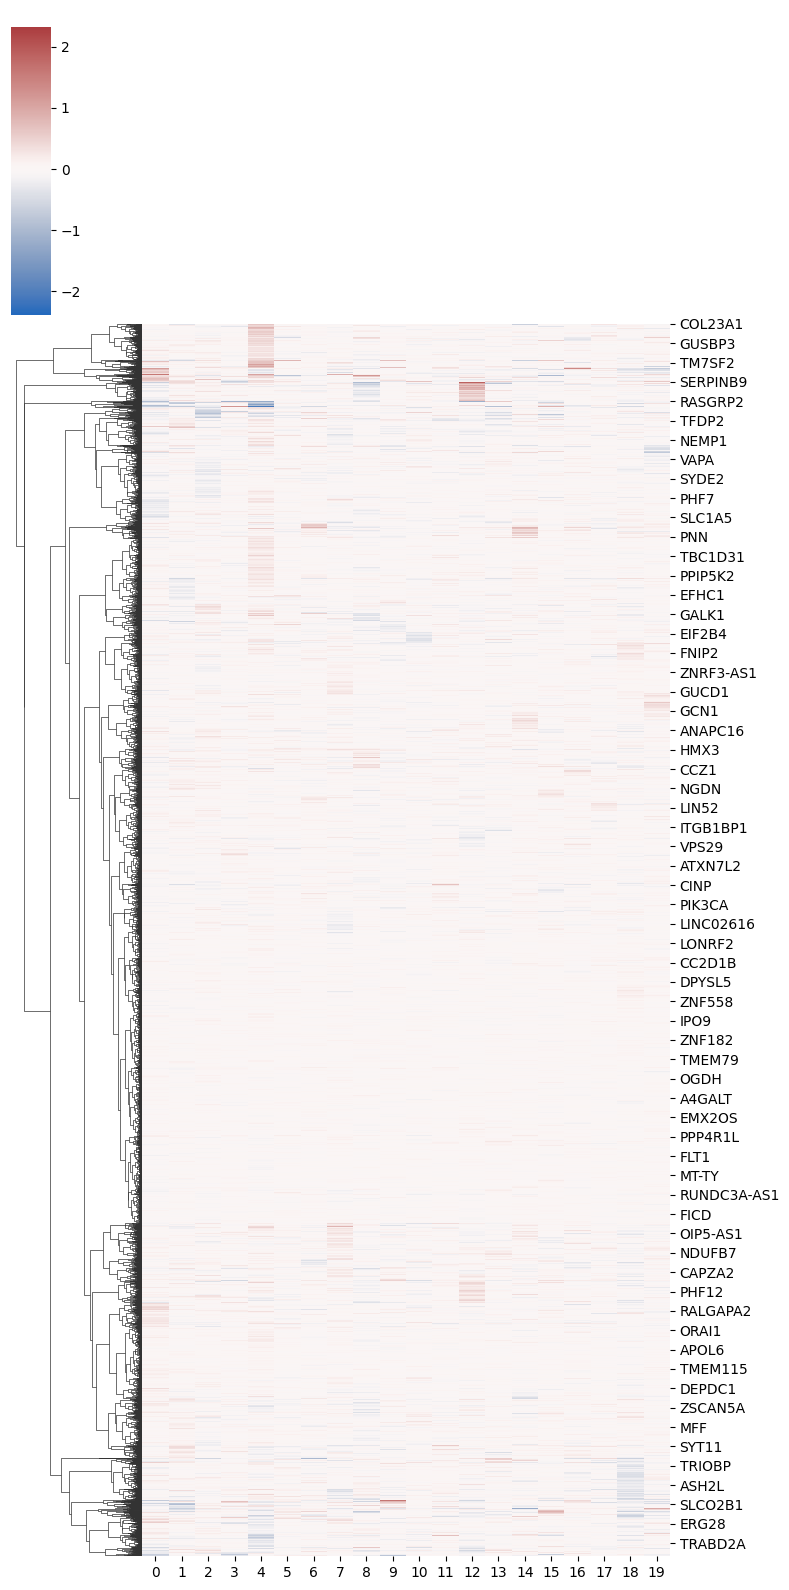

In [61]:
# len(merge_df)
# len(sceptre_df)
# model.module.guide.median()['element_x_factor'].min()
pert_loadings = model.module.guide.median()["pert_loadings"].squeeze()
# factor_x_gene_z_score = (loc/scale).detach().numpy()

factor_x_gene_df = pd.DataFrame(pert_loadings, columns=mdata["rna"].var_names)
# sns.heatmap(factor_x_gene_df, cmap="vlag", center=0, vmin=-5, vmax=5)

sns.clustermap(factor_x_gene_df.T, cmap="vlag", center=0, method="ward", figsize=(8,16), col_cluster=False)


In [62]:
# factor_x_gene_df.loc[5].sort_values()[-20:].index

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


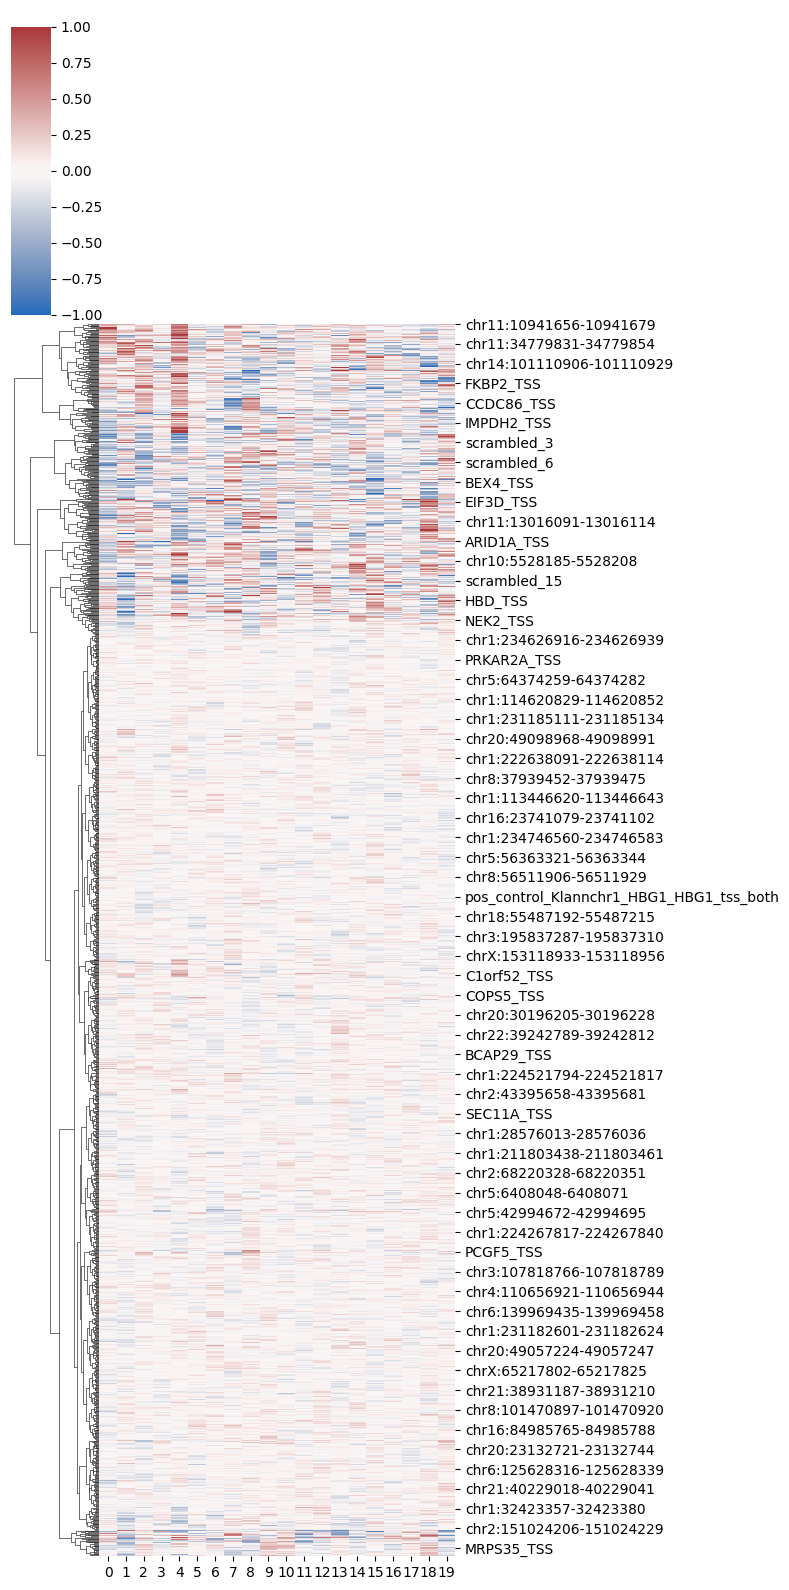

In [63]:
pert_factors = model.module.guide.median()["pert_factors"].squeeze()
# element_x_factor_z_score = (loc/scale).detach().numpy()

element_x_factor_df = pd.DataFrame(pert_factors, columns=mdata["grna"].varm["element_targeted"].columns)
# sns.heatmap(element_x_factor_df, cmap="vlag", center=0)

sns.clustermap(element_x_factor_df.T, cmap="vlag", center=0, vmin=-1, vmax=1, metric="euclidean", method="ward", figsize=(8, 16), col_cluster=False)

# biggest_gene = model.module.guide.median()['factor_x_gene'][biggest_factor_idx, :].argmax()
# biggest_element = model.module.guide.median()['element_x_factor'][:, biggest_factor_idx].argmax()

# elements =  mdata['grna'].varm['element_targeted'].columns
# genes = mdata['rna'].var_names

# plt.bar(x=values[:10].numpy(), height=)

# mdata['grna'].varm['element_targeted'].columns[int(biggest_element)]
# mdata['rna'].var_names[int(biggest_gene)]

In [64]:
n_print = 20
for i in range(element_x_factor_df.shape[0]):
    print("Factor " + str(i))
    print("Perturbations:", ','.join(element_x_factor_df.loc[i].abs().nlargest(n_print).index.tolist()))
    print("Genes:", ','.join(factor_x_gene_df.loc[i].abs().nlargest(n_print).index.tolist()))
    


Factor 0
Perturbations: chr11:33958518-33958541,chr11:33966182-33966205,chr11:33963092-33963115,chr12:131715611-131715634,chr14:101221980-101222003,chr12:131713939-131713962,random_7,random_15,chr10:74020210-74020233,NMU_TSS,chr15:80346436-80346459,chr11:65246109-65246132,chr11:74807780-74807803,random_18,chr12:98972605-98972628,chr11:75944834-75944857,SMARCC1_TSS,U2SURP_TSS,chr13:48736080-48736103,random_21
Genes: CD3G,ID3,ANKRD55,TLE2,ATF7IP2,H19,DDIT3,DLK1,MDK,CRLF1,PHLDA2,UBE2L6,DDIT4,IGFL2-AS1,ATG16L2,PIF1,CASTOR2,U2AF1,PSRC1,CENPA
Factor 1
Perturbations: chr12:57381970-57381993,MAX_TSS,chr12:53758967-53758990,SRRM1_TSS,ZNHIT1_TSS,ARID1A_TSS,chr11:60631332-60631355,random_16,NR2F2_TSS,chr12:120754676-120754699,SMARCC1_TSS,chr11:34779831-34779854,MYC_TSS,BEX4_TSS,scrambled_3,chr11:60931725-60931748,chr12:22145632-22145655,NUDT4_TSS,EIF4A3_TSS,RBBP4_TSS
Genes: HBD,BATF3,VEPH1,TAFA2,HBE1,CD52,SLCO2B1,CAVIN1,NEAT1,CRLF1,TMEM158,HBG1,CALB1,SH3BGRL3,AKR1C1,HBG2,LINC00520,OR2AT4,RGS16,CA

In [65]:
import ipywidgets as widgets
from IPython.display import display

# guide_1 = f"{plot_gene}_TSS|1"
# guide_2 = f"{plot_gene}_TSS|2"

gene_select = widgets.Dropdown(
    options=sorted(mdata['rna'].var_names),
    value=mdata['rna'].var_names[0],
    # rows=10,
    description='Gene',
    disabled=False
)


guide_select = widgets.Dropdown(
    options=sorted(mdata['grna'].var_names),
    value=mdata['grna'].var_names[0],
    # rows=10,
    description='Guide',
    disabled=False
)

display(gene_select, guide_select)

Dropdown(description='Gene', index=5611, options=('A4GALT', 'AAAS', 'AACS', 'AARS2', 'AARSD1', 'AASDH', 'AATK'…

Dropdown(description='Guide', options=('ACTB_TSS|1', 'ACTB_TSS|2', 'ACTG1_TSS|1', 'ACTG1_TSS|2', 'ACYP1_TSS|1'…

In [66]:
# import scanpy as sc

# plot_guides = ['TMED10_TSS|1','TMED10_TSS|2']
# plot_genes = ['TMED10', 'KDELR2','KDELR3','SEC13', 'YIF1A', 'CALU', 'YIPF2', 'SDF2L1', 'MANF']

plot_genes = [gene_select.value]
plot_guides = [guide_select.value]


counts_df = mdata["rna"][:, plot_genes].to_df()
guide_obs = mdata["grna"][:, plot_guides].X.sum(axis=1).copy().astype(bool)
counts_df['guide_obs']=guide_obs


# mdata['rna'].obs['TMED10_TSS'] = guide_obs
# mdata['rna'].obs['TMED10_TSS']=mdata['rna'].obs['TMED10_TSS'].astype("category")
# # mdata['rna'].raw = mdata['rna']
# # sc.pp.normalize_total(mdata['rna'])
# with plt.rc_context({'figure.dpi':200}):
#   sc.pl.dotplot(mdata['rna'], plot_genes, groupby='TMED10_TSS', title='TMED10_TSS')

(0.0, 50.0)

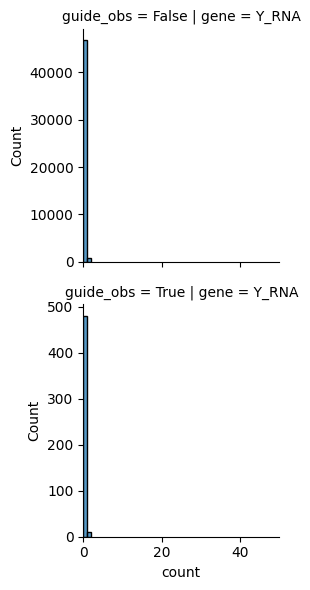

In [67]:
# plot_gene = gene_select.value
# plot_guide = guide_select.value
# print(plot_gene, plot_guide)

# plot_df = pd.DataFrame({"count": counts, "has_guide": guide_obs})
plot_df = counts_df.melt(id_vars='guide_obs',var_name='gene',value_name='count')
g = sns.FacetGrid(plot_df, col="gene", row="guide_obs",sharey=False)
g.map_dataframe(
    sns.histplot,
    x="count", binwidth=1,
    hue_order=[False,True],
    # log_scale=[False,True]
)
plt.xlim(0,50)
# plt.semilogy()

# sns.histplot(
#     plot_df.query('has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# plt.show()
# sns.histplot(
#     plot_df.query('not has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# # plt.xlim(0, 50)
# g.title(f"gene: {plot_gene}, guide: {plot_guide}")
# plt.show()



In [68]:
!pwd

/Users/ljb80/Projects/perturbo/docs/notebooks


In [69]:
import altair as alt

alt.Chart(subset_results).mark_point().encode(
  x='z_value',
  y='SCEPTRE_z_value',
  color='is_target',
  tooltip=['guide','gene', 'z_value', 'SCEPTRE_z_value'] 
).interactive()


ModuleNotFoundError: No module named 'altair'

#### scpower_df.to_csv(f"{data_dir}/scpower_results.csv")